In [1]:
#导入常用库
import sys
import pandas as pd
import os
import random
import shutil
import sklearn
import scipy
import numpy as np
import radiomics  #这个库专门用来提取特征
import SimpleITK as sitk  #读取nii文件
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV#导入Lasso工具包LassoCV
from sklearn.preprocessing import StandardScaler#标准化工具包StandardScaler
# import seaborn as sns
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
model_name='model_forest1.model'

# radio_datapath=r"<PROJECT_ROOT>\radiology\washout-subregiuon.csv"
# radio_datapath = r"<PROJECT_ROOT>\radiology\subregion_all_radiology_2025-04-16.csv"
# in_datapath = r"<PROJECT_ROOT>\radiology\washin_radiology_2024-10-30.csv"
out_datapath = r"<PROJECT_ROOT>\radiology\washout_radiology_2025-07-10.csv"

# radio_data=pd.read_csv(radio_datapath)
# in_data=pd.read_csv(in_datapath)
out_data=pd.read_csv(out_datapath)

out_data.head()

,index,patient_name,label_name,grade,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,...,wavelet-LLL_gldm_GrayLevelNonUniformity,wavelet-LLL_gldm_GrayLevelVariance,wavelet-LLL_gldm_HighGrayLevelEmphasis,wavelet-LLL_gldm_LargeDependenceEmphasis,wavelet-LLL_gldm_LargeDependenceHighGrayLevelEmphasis,wavelet-LLL_gldm_LargeDependenceLowGrayLevelEmphasis,wavelet-LLL_gldm_LowGrayLevelEmphasis,wavelet-LLL_gldm_SmallDependenceEmphasis,wavelet-LLL_gldm_SmallDependenceHighGrayLevelEmphasis,wavelet-LLL_gldm_SmallDependenceLowGrayLevelEmphasis
0,0,1,Untitled.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,155.155844,2.466664,33.146753,124.527273,4799.580519,4.428588,0.056493,0.034204,0.922140,0.003817
1,1,10,Untitled.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,233.309715,3.195620,23.739226,101.537619,1586.681519,10.175873,0.082290,0.038883,1.699827,0.002230
2,2,101,101-shenmengyun=2021.12.07.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,49.158730,3.526732,28.685714,44.225397,881.092063,3.298124,0.065369,0.126404,6.544463,0.007033
3,3,102,Untitled.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,1003.489568,3.777099,43.745301,113.358190,3814.354266,3.700109,0.031958,0.075700,5.829514,0.002176
4,4,103,Untitled.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,45.682731,2.312608,17.771084,55.771084,709.120482,10.981317,0.133756,0.056336,1.363555,0.003980


In [6]:
import pandas as pd

# 读取筛选条件表
filter_df = pd.read_csv(r'<PROJECT_ROOT>\datas_clear_final.csv')  # 包含 patient_name, label_name, grade

# print(in_sub_data[['patient_name', 'label_name', 'grade']].isin(filter_df[['patient_name', 'label_name', 'grade']]))


for df in [out_data, filter_df]:
    df['patient_name'] = df['patient_name'].astype(str)
    df['label_name'] = df['label_name'].astype(str)
    df['grade'] = df['grade'].astype(int)


def filter_df_by_conditions(df, filter_df):
    # 合并方式：inner join（多列匹配）
    merged = df.merge(filter_df, on=['patient_name', 'label_name','grade'], how='inner')
    return merged



# in_sub_data = filter_df_by_conditions(in_sub_data, filter_df)
# out_sub_data = filter_df_by_conditions(out_sub_data, filter_df)
out_data = filter_df_by_conditions(out_data, filter_df)
# out_data = filter_df_by_conditions(out_data, filter_df)

print("过滤条件数：", len(filter_df))
print("筛选结果行数（in_sub_data）：", len(out_data))

过滤条件数： 712
筛选结果行数（in_sub_data）： 712


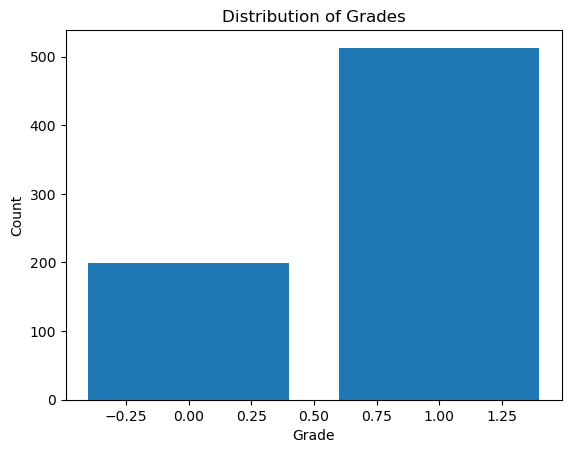

grade
1    513
0    199
Name: count, dtype: int64


In [7]:
# 查看总数据类别是否平衡
fig, ax = plt.subplots()
# sns.set()
# ax = sns.countplot(x='grade',hue='grade',data=radio_data)
# print(radio_data['grade'].value_counts())

# 计算每个类别的计数
grade_counts = out_data['grade'].value_counts()

# 绘制条形图
plt.bar(grade_counts.index, grade_counts.values)

# 添加标签和标题
plt.xlabel('Grade')
plt.ylabel('Count')
plt.title('Distribution of Grades')

# 显示图表
plt.show()

# 打印类别计数
print(grade_counts)

In [31]:
from pandas.core.common import random_state

#查看总体数据情况
print("一共有{}行特征数据".format(out_data.shape[0]))
# print("一共有{}列不同特征".format(radio_data.shape[1]))
#再把特征值数据和标签数据分开
# x1=radio_data[radio_data.columns[3:-46]]
# x2=radio_data[radio_data.columns[-23:-4]]
# x1 = x1.reset_index(drop=True)
# x2 = x2.reset_index(drop=True)

# x1 = radio_data[radio_data.columns[4:]]
# x2 = in_data[in_data.columns[4:]]
x = out_data[out_data.columns[4:-5]]

# x2 = x2.add_prefix('*')  # 给 x2 的列名添加前缀 "x2_"
# x3 = x3.add_prefix('**')  # 给 x3 的列名添加前缀 "x3_"

# x = pd.concat([ x1, x3], axis=1)
print("一共有{}列不同特征".format(x.shape[1]))
y = out_data['grade']
# 取X的5行看看数据
x.head()

一共有712行特征数据
一共有1167列不同特征


,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,wavelet-LLL_gldm_GrayLevelNonUniformity,wavelet-LLL_gldm_GrayLevelVariance,wavelet-LLL_gldm_HighGrayLevelEmphasis,wavelet-LLL_gldm_LargeDependenceEmphasis,wavelet-LLL_gldm_LargeDependenceHighGrayLevelEmphasis,wavelet-LLL_gldm_LargeDependenceLowGrayLevelEmphasis,wavelet-LLL_gldm_LowGrayLevelEmphasis,wavelet-LLL_gldm_SmallDependenceEmphasis,wavelet-LLL_gldm_SmallDependenceHighGrayLevelEmphasis,wavelet-LLL_gldm_SmallDependenceLowGrayLevelEmphasis
0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",2eb8445e1f9627f0281bd6f2fc557c24fc264955,3D,"(1.4062999486923218, 1.4062999486923218, 1.5)",...,155.155844,2.466664,33.146753,124.527273,4799.580519,4.428588,0.056493,0.034204,0.922140,0.003817
1,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",313e38ffdb7a17143e0d30bb8b825e092c5a3a6c,3D,"(0.7031000256538391, 0.7031000256538391, 1.500...",...,233.309715,3.195620,23.739226,101.537619,1586.681519,10.175873,0.082290,0.038883,1.699827,0.002230
2,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",08885ced249ff60a455370c26409f262acea3cc7,3D,"(0.7031000256538391, 0.7031000256538391, 0.699...",...,49.158730,3.526732,28.685714,44.225397,881.092063,3.298124,0.065369,0.126404,6.544463,0.007033
3,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",c8a4bd91511a11ca861b0e63d52447a524d58172,3D,"(0.7031000256538391, 0.7031000256538391, 0.699...",...,1003.489568,3.777099,43.745301,113.358190,3814.354266,3.700109,0.031958,0.075700,5.829514,0.002176
4,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {'sigma': [1.0, 3.0, 5...",364e24780d4005be0eb1e8ac63dc9a781c236cd1,3D,"(0.7031000256538391, 0.7031000256538391, 0.799...",...,45.682731,2.312608,17.771084,55.771084,709.120482,10.981317,0.133756,0.056336,1.363555,0.003980


In [10]:
# 区分训练集和测试集
from sklearn.model_selection import train_test_split
from sklearn import datasets
seed=114514
# 30%用于测试集，70%用于训练集
X_train,X_test,y_train,y_test= train_test_split(x,y,test_size=0.3, stratify=y, random_state=seed)
pd_train=pd.DataFrame(X_train)
train_index=np.array(pd_train.index)
# np.savetxt('../../data/trian_test_csv/train.txt',train_index.astype('int'))
#
# pd_test=pd.DataFrame(X_test)
# test_index=np.array(pd_test.index)
# np.savetxt('../../data/trian_test_csv/test.txt',test_index.astype('int'))
# 打印验证是否随机
print(train_index)

[113 170 282 504 644 534 328 324 241 372  78 530 423 248 269 561 245  15
 660 621  94 602 146  99  92 440 104 272 443 407  50  68 482 636 110 643
 707 578 511  53 290 459 312  80 379 502 702 587 473 463 477 249 309 614
 155 695 517 427 691 692 250 227  95 333 465 317 187 251 118 147 225  70
 188 371 673 386 399 134 474 261 335  14 653  37 293 635 343 487   2 234
 563 298 183 649 486 172 686 148 499  75 586 145 662 672 266 260 276 367
 314 684 453 488 595 554 553 470  57 640 195 352  28  83 611  12 701 566
 374 645 392   4 394 466 304 539 647 514 174  13  51 143 682 138 189 632
 625 417 558 412 294 137 288 166 331 544 259 406  89 313 149  87 354 186
 628 236 238 393 536  74  25 405 125 462  10 297 131 420 300 408 500 200
 680 397 434 280  82 416 527 634   1 510 360 377 228 202 571  65 507 175
 219 106 301 535 460 461 639 493 223 638 204 656 698  20 583 355 373 454
 424 531 538 182   8 568 696 132 190 606  73  72 550   9  39 271  61 150
 214 206 348 203  98  81 584 321 230 205 179 444 24

# 特征筛选方法

In [11]:
# T检验特诊筛选

#通过T检验从106个特征筛选
from scipy.stats import levene, ttest_ind
counts = 0
columns_index =[]
# print(X_train[y_train==0])
for column_name in X_train.columns[1:]:
    # print(column_name)
    print("\033[1;31;40m"+column_name+"\033[0m")
    try:
        if levene(X_train[y_train==0][column_name], X_train[y_train==1][column_name])[1] > 0.05:
            if ttest_ind(X_train[y_train==0][column_name], X_train[y_train==1][column_name],equal_var=True)[1] < 0.05:
                columns_index.append(column_name)
        else:
            if ttest_ind(X_train[y_train==0][column_name], X_train[y_train==1][column_name],equal_var=False)[1] < 0.05:
                columns_index.append(column_name)
    except Exception as ex:
        print("出现如下异常: %s"%ex)
        continue

print("筛选后剩下的特征数：{}个".format(len(columns_index)))

diagnostics_Versions_Numpy
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_SimpleITK
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_PyWavelet
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_Python
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Configuration_Settings
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Configuration_Enabled

In [6]:
# T检验特诊筛选

#通过T检验从106个特征筛选
from scipy.stats import levene, ttest_ind
counts = 0
columns_index =[]
# print(X_train[y_train==0])
for column_name in X_train.columns[1:]:
    # print(column_name)
    print("\033[1;31;40m"+column_name+"\033[0m")
    try:
        if levene(X_train[y_train==0][column_name], X_train[y_train==1][column_name])[1] > 0.05:
            if ttest_ind(X_train[y_train==0][column_name], X_train[y_train==1][column_name],equal_var=True)[1] < 0.05:
                columns_index.append(column_name)
        else:
            if ttest_ind(X_train[y_train==0][column_name], X_train[y_train==1][column_name],equal_var=False)[1] < 0.05:
                columns_index.append(column_name)
    except Exception as ex:
        print("出现如下异常: %s"%ex)
        continue

print("筛选后剩下的特征数：{}个".format(len(columns_index)))

diagnostics_Versions_Numpy
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_SimpleITK
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_PyWavelet
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_Python
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Configuration_Settings
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Configuration_Enabled

In [12]:
print(columns_index)

['diagnostics_Mask-original_VoxelNum', 'diagnostics_Image-interpolated_Minimum', 'diagnostics_Image-interpolated_Maximum', 'diagnostics_Mask-interpolated_VoxelNum', 'diagnostics_Mask-interpolated_Mean', 'diagnostics_Mask-interpolated_Minimum', 'diagnostics_Mask-interpolated_Maximum', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn', 'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice', 'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength', 'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean', 'original_firstorde

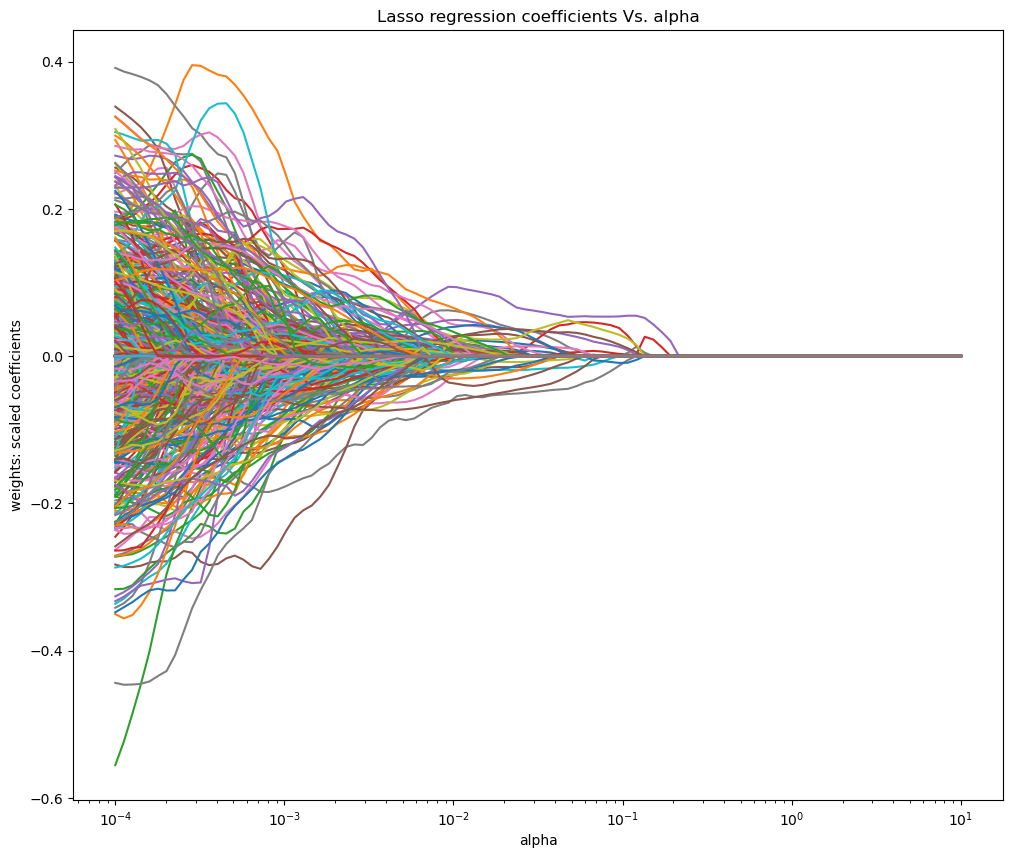

In [13]:
from sklearn.linear_model import Lasso

# 标准化数据
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.loc[:, columns_index])

alpha_lasso = 10**np.linspace(-4,1,100)
lasso = Lasso()
coefs_lasso = []

for i in alpha_lasso:
    lasso.set_params(alpha = i)
    lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(lasso.coef_)

plt.figure(figsize=(12,10))
ax = plt.gca()
ax.plot(alpha_lasso, coefs_lasso)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights: scaled coefficients')
plt.title('Lasso regression coefficients Vs. alpha')
# plt.legend(y)
plt.show()

In [22]:
# coef = pd.Series(Lasso.coef_, index=columns_index)
# print(coef[coef !=0])

In [14]:
#再把特征值数据和标签数据分开
x = X_train.loc[:,columns_index]
y = y_train
#先保存X的列名
columnNames = x.columns

lassoCV_x = x.astype(np.float32)#把x数据转换成np.float格式
lassoCV_y = y

standardscaler = StandardScaler()
lassoCV_x = standardscaler.fit_transform(lassoCV_x)#对x进行均值-标准差归一化
lassoCV_x = pd.DataFrame(lassoCV_x,columns=columnNames)#转 DataFrame 格式

# 形成5为底的指数函数
# 5**（-3） ~  5**（-2）
alpha_range = np.logspace(-3,0,500,base=5)
#alpha_range在这个参数范围里挑出aplpha进行训练，cv是把数据集分5分，进行交叉验证，max_iter是训练1000轮
lassoCV_model = LassoCV(alphas=alpha_range,cv=5,max_iter=1000)
#进行训练
lassoCV_model.fit(lassoCV_x,lassoCV_y)

#打印训练找出来的入值
print(lassoCV_model.alpha_)
# print("Coefficient of the model:{}".format(lassoCV_model.coef_) )
# print("intercept of the model:{}".format(lassoCV_model.intercept_))

coef = pd.Series(lassoCV_model.coef_, index=columnNames)
print("从原来{}个特征，筛选剩下{}个".format(len(columnNames),sum(coef !=0)))
print("分别是以下特征")
print(coef[coef !=0])
index = coef[coef !=0].index
lassoCV_x = lassoCV_x[index]
# lassoCV_x.head()

0.02341730452777825
从原来828个特征，筛选剩下28个
分别是以下特征
original_shape_Sphericity                                      -0.015037
original_firstorder_Median                                     -0.050765
log-sigma-1-0-mm-3D_glrlm_LongRunHighGrayLevelEmphasis          0.005592
log-sigma-1-0-mm-3D_glrlm_RunVariance                           0.036772
log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized      -0.019088
log-sigma-1-0-mm-3D_glszm_ZoneEntropy                           0.005285
log-sigma-3-0-mm-3D_glszm_SmallAreaEmphasis                     0.017527
log-sigma-3-0-mm-3D_gldm_DependenceNonUniformityNormalized      0.008600
log-sigma-5-0-mm-3D_firstorder_Maximum                          0.001791
log-sigma-5-0-mm-3D_glszm_SmallAreaEmphasis                     0.001901
log-sigma-5-0-mm-3D_gldm_LargeDependenceLowGrayLevelEmphasis   -0.008026
wavelet-LLH_firstorder_Median                                   0.013406
wavelet-LLH_glcm_Idn                                            0.066583
wavel

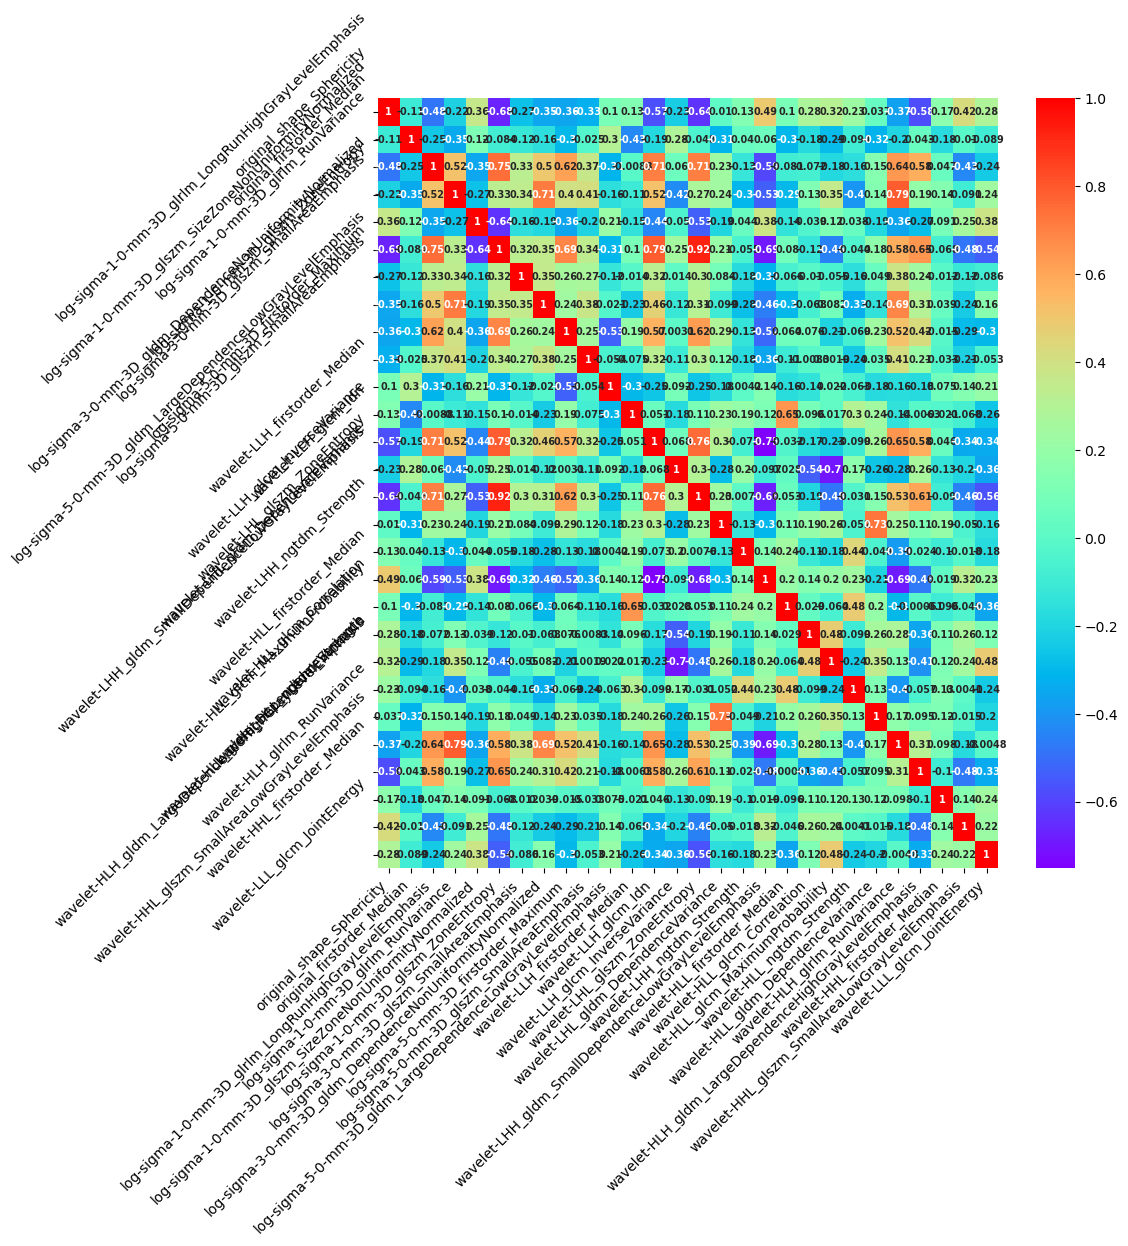

In [15]:
#绘制特征相关系数热力图
import seaborn as sns

# 根据相关性筛选
# corr_matix=lassoCV_x.corr()
# # m=~(corr_matix.mask(np.eye(len(corr_matix),dtype=bool)).abs()>0.75).any()
# # n=(corr_matix.mask(np.eye(len(corr_matix),dtype=bool)).abs()>0.75).any()
# # raw=corr_matix.loc[m,m]
# # raw_n=corr_matix.loc[n,n]
# # raw_n
# def count_high_corr(matirx, high_corr, threshold=0.5):
#     for i in range(matirx.shape[0]):
#         np_raw=np.array(matirx.iloc[i,:])
#         result=np.argwhere(np.abs(np_raw)>threshold).tolist()
#         result=[int(i[0]) for i in result]
#         high_corr[i]=len(result)
#     return high_corr
#
# hash_map=np.array(range(corr_matix.shape[0]))
# Flag=True
# high_corr=np.ones_like(hash_map)
# # corr_matix=np.array(corr_matix)
# r_list=[]
# while Flag:
#     origin_high_count=count_high_corr(corr_matix,high_corr)
#     # print(corr_matix.shape)
#     result=np.argmax(origin_high_count)
#     depend=np.max(origin_high_count)
#     if depend==1:
#         Flag=False
#         break
#     r_list.append(result)
#     # print(result)
#     high_corr[result]=0
#     # print(high_corr)
#     corr_matix.iloc[result,:]=0
#     corr_matix.iloc[:,result]=0
#     # print(corr_matix.shape)
#     # corr_matix.head()
#
# hash_map=np.delete(hash_map,r_list)
# corr_matix=lassoCV_x.corr().iloc[hash_map,hash_map]

# 画出热力图
f, ax= plt.subplots(figsize = (10, 10))
sns.heatmap(lassoCV_x.corr(),cmap='rainbow',annot=True,annot_kws={'size':7,'weight':'bold', },ax=ax)#绘制混淆矩阵
ax.set_xticklabels(ax.get_xticklabels(), rotation=45,va="top",ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
plt.show()


In [25]:
# index=corr_matix.index
# lassoCV_x = lassoCV_x[index]
# coef = coef.loc[index]
# print(coef.shape)

In [12]:
weight = coef[np.abs(coef)>0.02].to_dict()

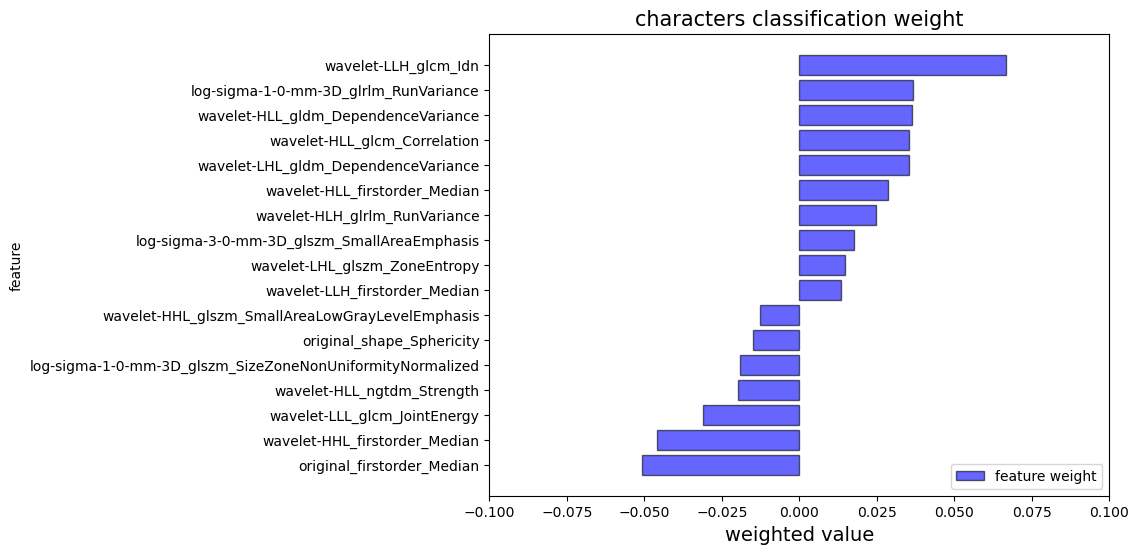

,0
original_firstorder_Median,-0.050765
wavelet-HHL_firstorder_Median,-0.045780
wavelet-LLL_glcm_JointEnergy,-0.031090
wavelet-HLL_ngtdm_Strength,-0.019786
log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized,-0.019088
original_shape_Sphericity,-0.015037
wavelet-HHL_glszm_SmallAreaLowGrayLevelEmphasis,-0.012811
wavelet-LLH_firstorder_Median,0.013406
wavelet-LHL_glszm_ZoneEntropy,0.014640
log-sigma-3-0-mm-3D_glszm_SmallAreaEmphasis,0.017527


In [18]:
#画一个特征系数的柱状图
weight = coef[np.abs(coef)>0.01].to_dict()
#根据值大小排列一下
weight = dict(sorted(weight.items(),key=lambda x:x[1],reverse=False))
plt.figure(figsize=(8,6))#设置画布的尺寸
plt.title('characters classification weight',fontsize=15)#标题，并设定字号大小
plt.xlabel(u'weighted value',fontsize=14)#设置x轴，并设定字号大小
plt.ylabel(u'feature')
plt.barh(range(len(weight.values())), list(weight.values()),tick_label = list(weight.keys()),alpha=0.6, facecolor = 'blue', edgecolor = 'black', label='feature weight')
plt.xlim([-0.1,0.1])
plt.legend(loc=4)#图例展示位置，数字代表第几象限
plt.show()
pd_weight=pd.DataFrame(coef[np.abs(coef)>0.01])
pd_weight=pd_weight.sort_values(by=0)
pd_weight

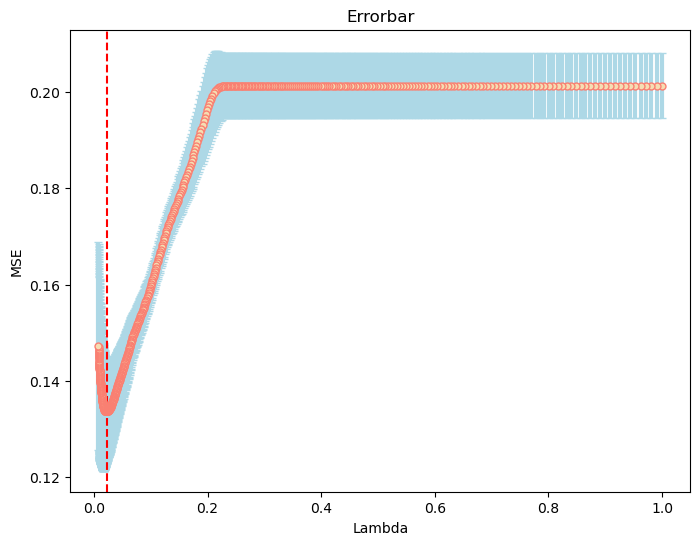

In [19]:
#绘制误差棒图
MSEs = lassoCV_model.mse_path_
mse = list()
std = list()
for m in MSEs:
    mse.append(np.mean(m))
    std.append(np.std(m))

plt.figure(figsize=(8,6))
plt.errorbar(lassoCV_model.alphas_, mse, std,fmt='o:',ecolor='lightblue',
			elinewidth=3,ms=5,mfc='wheat',mec='salmon',capsize=3)
plt.axvline(lassoCV_model.alpha_, color='red', ls='--')
plt.title('Errorbar')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.show()

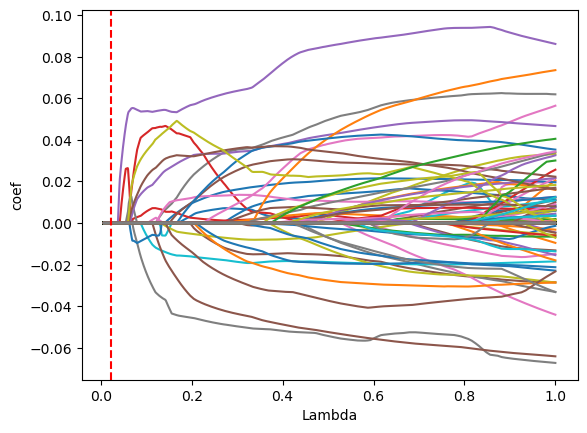

In [20]:
#再把特征值数据和标签数据分开
x = X_train.loc[:,columns_index]
y = y_train
#先保存X的列名
columnNames = x.columns
lassoCV_x = x.astype(np.float32)#把x数据转换成np.float格式
lassoCV_y = y
lassoCV_x = standardscaler.transform(lassoCV_x)#对x进行均值-标准差归一化
lassoCV_x = pd.DataFrame(lassoCV_x,columns=columnNames)#转 DataFrame 格式
coefs = lassoCV_model.path(lassoCV_x,lassoCV_y, alphas=alpha_range, max_iter=1000)[1].T
plt.plot(lassoCV_model.alphas,coefs,'-')
plt.axvline(lassoCV_model.alpha_, color='red', ls='--')
plt.xlabel('Lambda')
plt.ylabel('coef')
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay

In [22]:
from sklearn.model_selection import train_test_split #分割训练集和验证集
from sklearn.ensemble import RandomForestClassifier #导入随机森林分类器
import joblib #用来保存 sklearn 训练好的模型
#把数据分成训练集和验证集，7：3比例
index_ = pd_weight.index
rforest_x = x[index_]
rforest_y = y
standardscaler = StandardScaler()
rforest_x = standardscaler.fit_transform(rforest_x)#对x进行均值-标准差归一化
x1_train,x1_test, y1_train, y1_test = train_test_split(rforest_x,rforest_y,test_size=0.2, stratify=y, random_state=44)
seed=4
# model_forest = RandomForestClassifier(n_estimators=200,max_depth=13,max_features=1,random_state=seed).fit(x1_train,y1_train)
model_forest = SVC(kernel="linear", C=0.025,probability=True).fit(x1_train,y1_train)
# model_forest = MLPClassifier(alpha=0.1, max_iter=1000).fit(x1_train,y1_train)
score = model_forest.score(x1_test, y1_test)
print("在验证集上的准确率：{}".format(score))
#把随机森林的模型保存下来
model_path='./model'
model_name = 'out_svc0826.model'
if not os.path.exists(model_path):
    os.makedirs(model_path)
joblib.dump(model_forest, model_path+'/'+model_name)

在验证集上的准确率：0.84


['./model/out_svc0826.model']

In [23]:
from tabpfn import TabPFNClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # 必须使用imblearn的Pipeline
from sklearn.model_selection import cross_val_score

clf = TabPFNClassifier(
    random_state = 3407,     
    softmax_temperature=0.8,                # 提高预测锐度
    balance_probabilities=True, 
    memory_saving_mode=True,    
    device='cuda'
)  # 关键改动：添加 device='cuda' 参数

# model_forest = clf.fit(x1_train,y1_train)
model = Pipeline([
    ('sampler', SMOTE(sampling_strategy=0.8, random_state=114514)),  # 自动平衡至多数类数量
    ('classifier', clf)  # 同步启用权重保障
])
# model.fit(x1_train,y1_train)
# score = model.score(x1_test, y1_test)
scores = cross_val_score(model, rforest_x, rforest_y, cv=10, scoring='accuracy')
print("在验证集上的准确率：{}".format(scores.mean()))
model.fit(rforest_x, rforest_y)
#把随机森林的模型保存下来
model_path=r'<PROJECT_ROOT>\model'
model_name = 'out_tabpfn0826.model'
if not os.path.exists(model_path):
    os.makedirs(model_path)
joblib.dump(model, model_path+'/'+model_name)

在验证集上的准确率：0.8375102040816327


['<REDACTED_PATH>

In [24]:
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tabpfn import TabPFNClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # 必须使用imblearn的Pipeline
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold, cross_validate

N_REPEATS = 10  # 重复次数
N_SPLITS = 10   # 每次的折数

clf = TabPFNClassifier(
    random_state = 3407,     
    softmax_temperature=0.8,                # 提高预测锐度
    balance_probabilities=True, 
    memory_saving_mode=True,    
    device='cuda'
)  # 关键改动：添加 device='cuda' 参数

# model_forest = clf.fit(x1_train,y1_train)
model = Pipeline([
    ('sampler', SMOTE(sampling_strategy=0.8, random_state=42)),  # 自动平衡至多数类数量
    ('classifier', clf)  # 同步启用权重保障
])
# model.fit(x1_train,y1_train)
# score = model.score(x1_test, y1_test)

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=1028
)

# 评分函数，定义需要计算的指标
scoring = {
    'accuracy': 'accuracy',
    'sensitivity': make_scorer(recall_score),  # 召回率 (Sensitivity)
    'specificity': make_scorer(recall_score, pos_label=0),  # 特异度 (Specificity)，正类为0
    'precision': 'precision',
    'f1': 'f1',
    'auc': 'roc_auc'
}

# 使用cross_validate计算多个评分指标
scores = cross_validate(model, rforest_x, rforest_y, cv=cv, scoring=scoring)

# 打印交叉验证结果
print(f"完成 {N_REPEATS} 次 {N_SPLITS} 折交叉验证")
print("平均准确率: {:.3f} ± {:.3f}".format(np.mean(scores['test_accuracy']), np.std(scores['test_accuracy'])))
print("平均敏感性 (Sensitivity): {:.3f} ± {:.3f}".format(np.mean(scores['test_sensitivity']), np.std(scores['test_sensitivity'])))
print("平均特异性 (Specificity): {:.3f} ± {:.3f}".format(np.mean(scores['test_specificity']), np.std(scores['test_specificity'])))
print("平均精度 (Precision): {:.3f} ± {:.3f}".format(np.mean(scores['test_precision']), np.std(scores['test_precision'])))
print("平均F1分数: {:.3f} ± {:.3f}".format(np.mean(scores['test_f1']), np.std(scores['test_f1'])))
print("平均AUC: {:.3f} ± {:.3f}".format(np.mean(scores['test_auc']), np.std(scores['test_auc'])))

# 将所有的交叉验证结果保存为DataFrame
df_scores = pd.DataFrame({
    'repeat_id': np.repeat(np.arange(N_REPEATS), N_SPLITS),
    'fold_id': np.tile(np.arange(N_SPLITS), N_REPEATS),
    'accuracy': scores['test_accuracy'],
    'sensitivity': scores['test_sensitivity'],
    'specificity': scores['test_specificity'],
    'precision': scores['test_precision'],
    'f1': scores['test_f1'],
    'auc': scores['test_auc']
})

# 保存为CSV（添加元数据标题）
result_path = r'<PROJECT_ROOT>\eval_results'
csv_path = os.path.join(result_path, 'out_val_results_0826.csv')
df_scores.to_csv(csv_path, index=False, header=[
    'RepeatID', 'FoldID', 'Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1', 'AUC'
])

model.fit(rforest_x, rforest_y)

#把随机森林的模型保存下来
model_path=r'<PROJECT_ROOT>\model'
model_name = 'out_tabpfn0826.model'
if not os.path.exists(model_path):
    os.makedirs(model_path)
joblib.dump(model, model_path+'/'+model_name)

完成 10 次 10 折交叉验证
平均准确率: 0.837 ± 0.052
平均敏感性 (Sensitivity): 0.891 ± 0.052
平均特异性 (Specificity): 0.698 ± 0.133
平均精度 (Precision): 0.886 ± 0.046
平均F1分数: 0.887 ± 0.037
平均AUC: 0.875 ± 0.061


['<REDACTED_PATH>

In [25]:
import joblib
index = pd_weight.index
x_test_data = pd.DataFrame(X_test.loc[:,index])

columnNames = x_test_data.columns
x_test_data = x_test_data.astype(np.float32)

x_test_data = standardscaler.transform(x_test_data) #均值-标准差归一化
x_test_data = pd.DataFrame(x_test_data,columns=columnNames)
y_test_data = pd.DataFrame(y_test)

print("测试集一共有{}行特征数据，{}列不同特征".format(len(x_test_data),x_test_data.shape[1]))
#加载保存后的模型，然后进行预测


model_forest = joblib.load(model_path+'/'+model_name) #这是自己训练模型，记得替换自己的。
score = model_forest.score(x_test_data, y_test_data)
print("在测试集上的准确率：{}".format(score))

测试集一共有214行特征数据，17列不同特征
在测试集上的准确率：0.8177570093457944


In [26]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix
# index = pd_weight.index
# x_test_data = pd.DataFrame(X_test.loc[:,index])
# model_name = 'in_out_sub_2_tabpfn0422.model'

columnNames = x_test_data.columns
x_test_data = x_test_data.astype(np.float32)
x_test_data = pd.DataFrame(x_test_data,columns=columnNames)
y_test_data = pd.DataFrame(y_test)

print("测试集一共有{}行特征数据，{}列不同特征".format(len(x_test_data),x_test_data.shape[1]))
#加载保存后的模型，然后进行预测


model_forest = joblib.load(model_path+'/'+model_name) #这是自己训练模型，记得替换自己的。
score = model_forest.score(x_test_data, y_test_data)
print("在测试集上的准确率：{}".format(score))

# 计算其他评估指标
# 分类报告：包括 Precision, Recall (Sensitivity), F1-score
y_pred = model_forest.predict(x_test_data)
print("\n分类报告：")
print(classification_report(y_test_data, y_pred))

precision = precision_score(y_test_data, y_pred)
recall = recall_score(y_test_data, y_pred)
f1 = f1_score(y_test_data, y_pred)
# 混淆矩阵：用于计算 Specificity 和 Sensitivity
conf_matrix = confusion_matrix(y_test_data, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# Sensitivity（召回率） = TP / (TP + FN)
sensitivity = tp / (tp + fn)
# Specificity = TN / (TN + FP)
specificity = tn / (tn + fp)

# AUC (ROC曲线下的面积)
y_prob = model_forest.predict_proba(x_test_data)[:, 1]  # 获取正类的概率
auc_score = roc_auc_score(y_test_data, y_prob)

# 输出结果
print("\n整体结果:")
print(f"Sensitivity (召回率): {sensitivity:.4f}")
print(f"Specificity (特异性): {specificity:.4f}")
print(f"Precision (精确率): {precision:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc_score:.4f}")

# 创建一个包含实际类别和预测概率的 DataFrame
result_df = pd.DataFrame({
    'Actual': y_test_data.values.flatten(),  # 真实标签
    'Predicted_Prob': y_prob  # 预测的正类概率
})

# 保存为 CSV 文件
res_path = r"<PROJECT_ROOT>\test_result"
result_df.to_csv( res_path + r'\out_0826.csv', index=False)
print("预测概率和实际标签已保存至 'out_0428.csv'")

测试集一共有214行特征数据，17列不同特征
在测试集上的准确率：0.8177570093457944

分类报告：
              precision    recall  f1-score   support

           0       0.68      0.65      0.67        60
           1       0.87      0.88      0.87       154

    accuracy                           0.82       214
   macro avg       0.78      0.77      0.77       214
weighted avg       0.82      0.82      0.82       214


整体结果:
Sensitivity (召回率): 0.8831
Specificity (特异性): 0.6500
Precision (精确率): 0.8662
F1-score: 0.8746
AUC: 0.8413
预测概率和实际标签已保存至 'out_0428.csv'


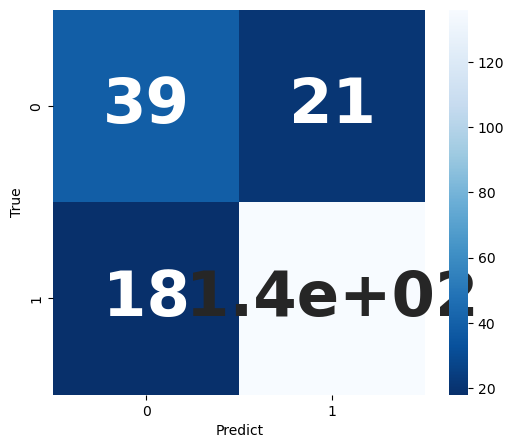

混淆矩阵为：
[[ 39  21]
 [ 18 136]]

计算各项指标：
              precision    recall  f1-score   support

           0       0.68      0.65      0.67        60
           1       0.87      0.88      0.87       154

    accuracy                           0.82       214
   macro avg       0.78      0.77      0.77       214
weighted avg       0.82      0.82      0.82       214



In [27]:
#绘制混淆矩阵
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
from sklearn.metrics import confusion_matrix

predict_label = model_forest.predict(x_test_data) # 预测的标签
label = y_test_data.values.tolist()  # 真实标签
confusion = confusion_matrix(label, predict_label) # 计算混淆矩阵

plt.figure(figsize=(6, 5))
sns.heatmap(confusion, cmap='Blues_r', annot=True, annot_kws={'size': 45, 'weight': 'bold'}) # 绘制混淆矩阵
plt.xlabel('Predict')
plt.ylabel('True')
plt.show()

print("混淆矩阵为：\n{}".format(confusion))
print("\n计算各项指标：")
print(classification_report(label, predict_label))


In [28]:
out_datapath = r"<NEW_ROOT>\radiology\washout_radiology_2025-07-11.csv"
val_data=pd.read_csv(out_datapath)

val_data.head()

filter_df = pd.read_csv(r'<NEW_ROOT>\datas_clear_pro.csv')  # 包含 patient_name, label_name, grade

# print(in_sub_data[['patient_name', 'label_name', 'grade']].isin(filter_df[['patient_name', 'label_name', 'grade']]))


for df in [val_data, filter_df]:
    df['patient_name'] = df['patient_name'].astype(str)
    df['label_name'] = df['label_name'].astype(str)
    df['grade'] = df['grade'].astype(int)


def filter_df_by_conditions(df, filter_df):
    # 合并方式：inner join（多列匹配）
    merged = df.merge(filter_df, on=['patient_name', 'grade'], how='inner')
    return merged
val_data = filter_df_by_conditions(val_data, filter_df)

print("过滤条件数：", len(filter_df))
print("筛选结果行数（in_data）：", len(val_data))

过滤条件数： 211
筛选结果行数（in_data）： 211


In [29]:
columns_index = pd_weight.index
x_val_data = val_data[columns_index]
y_val_data = val_data['grade']

print(x_val_data)
print(y_val_data)

     original_firstorder_Median  wavelet-HHL_firstorder_Median  \
0                      0.234450                       0.000248   
1                      0.083642                       0.000627   
2                      0.202731                      -0.001127   
3                      0.101870                      -0.000043   
4                      0.132940                      -0.000242   
..                          ...                            ...   
206                    0.036793                      -0.000436   
207                   -0.048540                      -0.000140   
208                   -0.006427                      -0.000710   
209                    0.058150                      -0.000648   
210                   -0.005357                      -0.000209   

     wavelet-LLL_glcm_JointEnergy  wavelet-HLL_ngtdm_Strength  \
0                        0.075633                    0.195217   
1                        0.290118                    0.007617   
2           

In [30]:
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tabpfn import TabPFNClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # 必须使用imblearn的Pipeline
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold, cross_validate

# N_SEEDS   = 1000               # 需要的随机种子数量
TEST_SIZE = 0.3                  # train/test 划分比例
CV_FOLDS  = 5                   # 10‑fold CV
RANDOM_BASE = 114514              # 生成种子列表的基准种子
RESULT_DIR = r"<PROJECT_ROOT>\eval_results-2"
MODEL_DIR  = r"<PROJECT_ROOT>\model-2"
CSV_NAME   = "out_top100_seeds.csv"
TEST_CSV   = "out_top100_seeds_test.csv"
EXT_CSV    = "out_top100_seeds_external.csv"
FINAL_MODEL_NAME = "out_top100.model"

scoring = {
    "accuracy": "accuracy",
    "sensitivity": make_scorer(recall_score, pos_label=1),
    "specificity": make_scorer(recall_score, pos_label=0),
    "precision": "precision",
    "f1": "f1",
    "auc": "roc_auc",
}

def compute_metrics(y_true, y_pred, y_proba):
    """返回六个指标的 dict"""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "specificity": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_proba),
    }

def build_pipeline(seed):
    """构建包含 StandardScaler、SMOTE、TabPFN 的 Pipeline"""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("sampler", SMOTE(sampling_strategy=0.9, random_state=seed)),
        ("classifier", TabPFNClassifier(
            random_state=seed,
            softmax_temperature=0.8,
            balance_probabilities=True,
            memory_saving_mode=True,
            device='cuda'   # 若无 GPU 改为 'cpu'
        )),
    ])

In [32]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_all = x
X_all = X_all[pd_weight.index]
y_all = y

print(X_all.shape)

def evaluate_one_seed(seed, x_val_data, y_val_data):
    """对单个随机种子完成划分、CV、Test、External 并返回结果列表"""
    # ① 训练/测试划分
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all,
        test_size=TEST_SIZE,
        stratify=y_all,
        random_state=seed,
    )
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ② 10‑fold CV（仅在训练集内部）
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    pipeline = build_pipeline(seed)
    cv_scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,               # 防止内部并行与外部并行冲突
        return_estimator=False,
    )

    # ③ 在完整训练集上再次 fit（用于后面的 Test / External 评估）
    pipeline.fit(X_train, y_train)

    # ④ Test 集评估
    y_test_pred = pipeline.predict(X_test)
    y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    test_metrics = compute_metrics(y_test, y_test_pred, y_test_proba)

    # ⑤ External 验证（若提供）
    external_metrics = None
    if x_val_data is not None and y_val_data is not None:
        x_val_scaled = scaler.transform(x_val_data)
        y_ext_pred = pipeline.predict(x_val_scaled)
        y_ext_proba = pipeline.predict_proba(x_val_scaled)[:, 1]
        
        external_metrics = compute_metrics(y_val_data, y_ext_pred, y_ext_proba)

    # ⑥ 整理所有行
    rows = []

    # CV 每折一行
    for fold_id in range(CV_FOLDS):
        rows.append({
            "seed": seed,
            "split_type": "CV",
            "repeat_id": 0,               # 本例中没有 repeat，仅占位
            "fold_id": fold_id,
            "accuracy": cv_scores["test_accuracy"][fold_id],
            "sensitivity": cv_scores["test_sensitivity"][fold_id],
            "specificity": cv_scores["test_specificity"][fold_id],
            "precision": cv_scores["test_precision"][fold_id],
            "f1": cv_scores["test_f1"][fold_id],
            "auc": cv_scores["test_auc"][fold_id],
        })

    # Test 一行
    rows.append({
        "seed": seed,
        "split_type": "TEST",
        "repeat_id": np.nan,
        "fold_id": np.nan,
        **test_metrics,
    })

    # External 一行（若有）
    if external_metrics is not None:
        rows.append({
            "seed": seed,
            "split_type": "EXTERNAL",
            "repeat_id": np.nan,
            "fold_id": np.nan,
            **external_metrics,
        })

    return rows

(712, 17)


In [33]:
# 使用100个可复现的随机种子
from tqdm.notebook import tqdm
from joblib import Parallel, delayed, dump
import joblib
# rng = np.random.RandomState(RANDOM_BASE)
# seed_list = rng.randint(300001, 400000, size=N_SEEDS)
seed_list = [2537, 10880, 132453, 42539, 149191, 21903, 38176, 148376, 109335, 21932,
    85431, 172241, 102225, 297262, 266651, 48322, 41855, 20322, 165600, 22096,
    238541, 160128, 8170, 10876, 176597, 60977, 272441, 19873, 24623, 273843,
    284060, 41744, 158808, 49641, 234691, 11975, 126250, 129794, 79842, 168393,
    7094, 232214, 137044, 19597, 266215, 108991, 53031, 285336, 174992, 243942,
    140470, 57264, 1746, 23071, 192121, 191306, 287145, 101180, 52765, 180735,
    112074, 40083, 197733, 93286, 204889, 226555, 57712, 140084, 71943, 185676,
    279288, 190760, 45149, 73280, 259534, 87578, 42474, 60495, 108145, 20879,
    59695, 290404, 8987, 76984, 98109, 19759, 89914, 104079, 202196, 70586,
    25537, 240437, 59147, 75810, 129464, 143460, 293508, 30130, 158100, 125463]

# 使用 joblib 并行执行；n_jobs=-1 使用全部 CPU 核心
all_rows = Parallel(n_jobs=-1, backend="loky", verbose=5)(
    delayed(evaluate_one_seed)(seed, x_val_data, y_val_data) for seed in tqdm(seed_list, desc="Seeds")
)

    # flatten
flat_rows = [row for sublist in all_rows for row in sublist]
df = pd.DataFrame(flat_rows)

# ------------------- 6. 保存 CSV -------------------
os.makedirs(RESULT_DIR, exist_ok=True)

# 统一的完整 CSV（包含 CV、TEST、EXTERNAL）
combined_path = os.path.join(RESULT_DIR, CSV_NAME)
df.to_csv(combined_path, index=False, encoding="utf-8")
print(f"✅ 完整结果已保存到 {combined_path}")

# 仅保留 TEST 行的 CSV
test_df = df.query("split_type == 'TEST'").drop(columns=["split_type"])
test_path = os.path.join(RESULT_DIR, TEST_CSV)
test_df.to_csv(test_path, index=False, encoding="utf-8")
print(f"✅ 测试集结果已保存到 {test_path}")

    # 仅保留 EXTERNAL 行的 CSV（若有外部验证集）
if x_val_data is not None:
    ext_df = df.query("split_type == 'EXTERNAL'").drop(columns=["split_type"])
    ext_path = os.path.join(RESULT_DIR, EXT_CSV)
    ext_df.to_csv(ext_path, index=False, encoding="utf-8")
    print(f"✅ 外部验证集结果已保存到 {ext_path}")
else:
    print("⚠️ 未提供外部验证集，跳过外部 CSV 的生成。")

    # ------------------- 7. 训练全量模型并保存 -------------------
final_pipe = build_pipeline(seed=RANDOM_BASE)
final_pipe.fit(X_all, y_all)

os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, FINAL_MODEL_NAME)
joblib.dump(final_pipe, model_path)
print(f"🗂️ 全量模型已保存到 {model_path}")

Seeds:   0%|          | 0/100 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done  58 out of 100 | elapsed:  4.1min remaining:  3.0min
[Parallel(n_jobs=-1)]: Done  79 out of 100 | elapsed:  5.6min remaining:  1.5min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.9min finished


✅ 完整结果已保存到 <PROJECT_ROOT>\eval_results-2\out_top100_seeds.csv
✅ 测试集结果已保存到 <PROJECT_ROOT>\eval_results-2\out_top100_seeds_test.csv
✅ 外部验证集结果已保存到 <PROJECT_ROOT>\eval_results-2\out_top100_seeds_external.csv
🗂️ 全量模型已保存到 <PROJECT_ROOT>\model-2\out_top100.model


In [34]:
# -------------------------------------------------
# ① 依据 split_type == "CV" 取出所有 CV 折的记录
cv_df = df[df["split_type"] == "CV"].copy()

# 需要统计的指标（与后面 compute_metrics 中保持一致）
metrics = ["accuracy", "sensitivity", "specificity", "precision", "f1", "auc"]

# ② 按 seed 分组，求 mean 与 std
cv_summary = (
    cv_df.groupby("seed")[metrics]
    .agg(["mean", "std"])                     # 生成 MultiIndex 列
    .reset_index()
)

# ③ 把 MultiIndex 的列名展平成 “metric_mean / metric_std”
cv_summary.columns = [
    f"{metric}_{stat}" if stat else metric
    for metric, stat in cv_summary.columns
]

# ④ 保存到 CSV（文件名自行修改）
cv_summary_path = os.path.join(RESULT_DIR, "out_top100_seeds_cv_summary.csv")
cv_summary.to_csv(cv_summary_path, index=False, encoding="utf-8")
print(f"✅ 10‑折 CV 均值/标准差已保存到 {cv_summary_path}")


✅ 10‑折 CV 均值/标准差已保存到 <PROJECT_ROOT>\eval_results-2\out_top100_seeds_cv_summary.csv


In [35]:
# -------------------------------------------------
# 为了拼接，先把 test / external 的列名加上后缀，防止冲突
# ① Test
test_df_clean = (
    test_df.drop(columns=["repeat_id", "fold_id"])
    .rename(columns=lambda c: f"{c}_test" if c not in ["seed"] else c)
)

# ② External（若提供）
if x_val_data is not None:
    ext_df_clean = (
        ext_df.drop(columns=["repeat_id", "fold_id"])
        .rename(columns=lambda c: f"{c}_external" if c not in ["seed"] else c)
    )
else:
    ext_df_clean = None

# -------------------------------------------------
# ③ 合并：先左连接 CV summary → Test → External
combined_df = cv_summary.merge(test_df_clean, on="seed", how="left")

if ext_df_clean is not None:
    combined_df = combined_df.merge(ext_df_clean, on="seed", how="left")

# -------------------------------------------------
# ④ 保存最终的拼接文件
combined_path = os.path.join(RESULT_DIR, "out_top100_seeds_all_combined.csv")
combined_df.to_csv(combined_path, index=False, encoding="utf-8")
print(f"✅ 所有信息已按列拼接并保存到 {combined_path}")


✅ 所有信息已按列拼接并保存到 <PROJECT_ROOT>\eval_results-2\out_top100_seeds_all_combined.csv


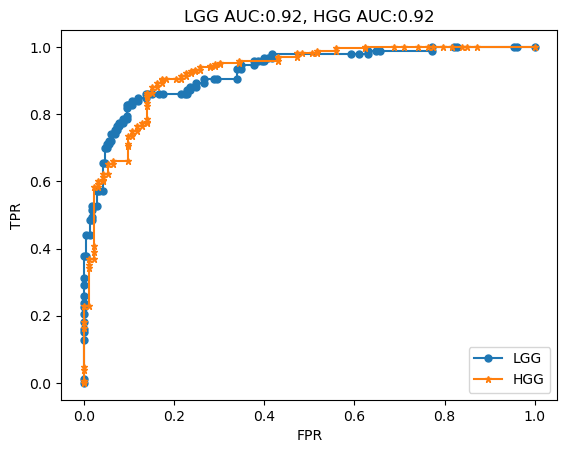

In [46]:
#绘制ROC曲线,方法1
from sklearn.metrics import roc_curve, roc_auc_score,auc
kind = {'HGG':1,"LGG":0}
model_forest = joblib.load(model_path+'/'+model_name)#这是自己训练模型，记得替换自己的
label = y_test_data.values.tolist()  #真实标签
y_predict = model_forest.predict_proba(x_test_data)#得到标签0和1对应的概率h
fpr , tpr ,threshold = roc_curve(label, y_predict[:,kind['LGG']], pos_label=kind['LGG'])
roc_auc = auc(fpr,tpr) #计算auc的
fpr1 , tpr1 ,threshold = roc_curve(label, y_predict[:,kind['HGG']], pos_label=kind['HGG'])
roc_auc1 = auc(fpr1,tpr1) #计算auc的
plt.plot(fpr, tpr,marker='o', markersize=5,label='LGG')
plt.plot(fpr1, tpr1,marker='*', markersize=5,label='HGG')
plt.title("LGG AUC:{:.2f}, HGG AUC:{:.2f}".format(roc_auc,roc_auc1))
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc=4)
plt.show()

In [35]:
# Code source: Gaël Varoquaux
#              Andreas Müller
# Modified for documentation by Jaques Grobler
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
import warnings


names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]
seed=4
classifiers = [
    KNeighborsClassifier(2),
    SVC(kernel="linear", C=0.025,probability=True,random_state=seed),
    SVC(gamma=2, C=1,probability=True,random_state=seed),
    GaussianProcessClassifier(1.0 * RBF(1.0),random_state=seed),
    DecisionTreeClassifier(max_depth=5,random_state=seed),
    RandomForestClassifier(max_depth=5, n_estimators=100, max_features=10,random_state=seed),
    MLPClassifier(alpha=1, max_iter=1000,random_state=seed),
    AdaBoostClassifier(random_state=seed),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

for name, clf in zip(names, classifiers):
    clf = make_pipeline(StandardScaler(), clf)
    clf.fit(rforest_x, rforest_y)
    pred_y= clf.predict(x_test_data)
    pred_y_proba = clf.predict_proba(x_test_data)
    accuracy=metrics.accuracy_score(y_test_data,pred_y)
    balanced_accuracy=metrics.balanced_accuracy_score(y_test_data,pred_y)
    f1_weighted=metrics.f1_score(y_test_data,pred_y)
    precision=metrics.precision_score(y_test_data,pred_y)
    sensitivity=metrics.precision_score(y_test_data,pred_y)
    tn,fp,fn,tp=confusion_matrix(y_test_data,pred_y).ravel()
    specificity=tn/(tn+fp)
    AUC=metrics.roc_auc_score(y_test_data,pred_y_proba[:,-1])
    print(name+'\n'+'accuracy: '+str(accuracy)[:6]
          +', sensitivity: '+str(sensitivity)[:6]
          +', specificity: '+str(specificity)[:6]
          +', precision: '+str(precision)[:6]
          +', f1_weighted: '+str(f1_weighted)[:6]
          +', AUC: '+str(AUC)[:6])
    # print(pred_y)
    # break
    # print(name+' '+str(score))

Nearest Neighbors
accuracy: 0.8181, sensitivity: 0.904, specificity: 0.8481, precision: 0.904, f1_weighted: 0.8496, AUC: 0.8635
Linear SVM
accuracy: 0.8590, sensitivity: 0.8481, specificity: 0.6962, precision: 0.8481, f1_weighted: 0.8963, AUC: 0.9157
RBF SVM
accuracy: 0.8454, sensitivity: 0.8057, specificity: 0.5696, precision: 0.8057, f1_weighted: 0.8924, AUC: 0.9029
Gaussian Process
accuracy: 0.6409, sensitivity: 0.6409, specificity: 0.0, precision: 0.6409, f1_weighted: 0.7811, AUC: 0.8712
Decision Tree
accuracy: 0.8045, sensitivity: 0.8450, specificity: 0.7215, precision: 0.8450, f1_weighted: 0.8480, AUC: 0.7891
Random Forest
accuracy: 0.8681, sensitivity: 0.8733, specificity: 0.7594, precision: 0.8733, f1_weighted: 0.9003, AUC: 0.9197
Neural Net
accuracy: 0.8681, sensitivity: 0.8943, specificity: 0.8101, precision: 0.8943, f1_weighted: 0.8975, AUC: 0.9296
AdaBoost
accuracy: 0.8909, sensitivity: 0.9333, specificity: 0.8860, precision: 0.9333, f1_weighted: 0.9130, AUC: 0.9201
Naive B

In [ ]:
index = pd_weight.index
rforest_x = X_train.loc[:,index]
rforest_x['label']=y_train
rforest_x.to_csv('model_data/train.csv')
x_test_data = X_test.loc[:,index]
x_test_data['label']=y_test_data
x_test_data.to_csv('model_data/test.csv')